In [1]:
from tqdm import tqdm
from omm.omm import ProteinImplicit
import mdtraj as md 
import numpy as np
import torch
import subprocess
from einops import rearrange, reduce, repeat
import os
import matplotlib.pyplot as plt

In [2]:
parent_dir = "/global/cfs/cdirs/m4235/boltz_files/bba/boltz_inference/boltz_results_bba_inference_step_1.6/predictions/bba/"
protein_name = "bba"


In [3]:
# load the diffusion structures as a concatenated pdb

diffusion_structures = []
file_list = [f for f in os.listdir(parent_dir) if f.endswith(".pdb") and f!= "all_diffusion_structures.pdb"]
file_list = sorted(file_list, key=lambda x: int(x.split("_")[-1].split(".")[0]))
print(file_list)


['bba_model_0.pdb', 'bba_model_1.pdb', 'bba_model_2.pdb', 'bba_model_3.pdb', 'bba_model_4.pdb', 'bba_model_5.pdb', 'bba_model_6.pdb', 'bba_model_7.pdb', 'bba_model_8.pdb', 'bba_model_9.pdb', 'bba_model_10.pdb', 'bba_model_11.pdb', 'bba_model_12.pdb', 'bba_model_13.pdb', 'bba_model_14.pdb', 'bba_model_15.pdb', 'bba_model_16.pdb', 'bba_model_17.pdb', 'bba_model_18.pdb', 'bba_model_19.pdb', 'bba_model_20.pdb', 'bba_model_21.pdb', 'bba_model_22.pdb', 'bba_model_23.pdb', 'bba_model_24.pdb', 'bba_model_25.pdb', 'bba_model_26.pdb', 'bba_model_27.pdb', 'bba_model_28.pdb', 'bba_model_29.pdb', 'bba_model_30.pdb', 'bba_model_31.pdb', 'bba_model_32.pdb', 'bba_model_33.pdb', 'bba_model_34.pdb', 'bba_model_35.pdb', 'bba_model_36.pdb', 'bba_model_37.pdb', 'bba_model_38.pdb', 'bba_model_39.pdb', 'bba_model_40.pdb', 'bba_model_41.pdb', 'bba_model_42.pdb', 'bba_model_43.pdb', 'bba_model_44.pdb', 'bba_model_45.pdb', 'bba_model_46.pdb', 'bba_model_47.pdb', 'bba_model_48.pdb', 'bba_model_49.pdb', 'bba_mode

In [4]:
# only run this once!

for filename in tqdm(file_list):
    if filename.endswith(".pdb"):
        diffusion_structures.append(md.load(f"{parent_dir}/{filename}"))
diffusion_structures = md.join(diffusion_structures)
diffusion_structures.save(f"{parent_dir}/all_diffusion_structures.pdb")

100%|██████████| 2000/2000 [00:46<00:00, 42.97it/s]


In [5]:
# otherwise just load the concatenated pdb

diffusion_structures = md.load(f"{parent_dir}/all_diffusion_structures.pdb")

In [6]:
def compute_force_from_traj(
    traj: md.Trajectory, 
    amber_filename:str, 
    num_relax_steps:int=0, 
    temperature:float=300
):
    """Compute the heavy atom forces at every trajectory frame.

    Parameters
    ----------
    traj : md.Trajectory
        Trajectory to compute forces for.
    amber_filename : str
        Name of the .prmtop and .(inp)crd files of the system.
    
    Notes
    -----
    Assumes kT units with T = 300 Kelvin unless otherwise specified.
    """    
    simulation_args = {
        "temperature": temperature, 
        "temperature_units": "kelvin", 
        "friction": 100.0, "dt": 0.00002, 
        "time_units": "picoseconds", 
        "prior_weight": None, 
        "integrator_to_use": "overdamped", 
        "do_energy_minimization": False, 
        "chk_freq": 10000000, 
        "device": "CUDA", 
        "fix":"backbone"
    }
    solvent_args = {
        "implicit_solvent": "OBC2", 
        "implicit_solvent_kappa": 0.1, 
        "implicit_solvent_kappa_length_units": "nanometer"
    }

    p = ProteinImplicit(
        filename = amber_filename, chk=0,
        simulation_args=simulation_args,
        solvent_args=solvent_args,
        save_filename = f"./"
        )

    gen_positions = traj.xyz # mdtraj saves in nanometers by default
    final_forces = []

    for i, position in tqdm(enumerate(gen_positions), mininterval=10):
        # Need to somehow add hydrogens to each position tensor. 
        pos, pe, ke, forces = p.relax_energies(
            10 * position, # convert to angstroms
            velocities=True,
            num_relax_steps=num_relax_steps, # 0 relax steps means no relaxation, just get energies
            length_units="angstroms",
            time_units="picoseconds",
            energy_units="kilocalories_per_mole",
            # energy_units="kT"
        )
        final_forces.append(forces)

    return np.stack(final_forces, axis=0)

In [7]:
# run the amber files to add missing hydrogens and OXT and save prmtop and crd files

tleap_input = f"""
    source leaprc.ff99SBxildn
    protein = loadPDB {parent_dir}/{file_list[0]}
    check protein
    savePdb protein amber_{protein_name}_single.pdb
    saveAmberParm protein amber_{protein_name}_single.prmtop amber_{protein_name}_single.crd
    quit
    """

result = subprocess.run(
    ["tleap", "-f", "-"],  # "-" means read from stdin
    input=tleap_input.encode(),
    stdout=subprocess.DEVNULL,  # suppress normal output
    check=True
)

# diffusion iid inference traj
traj_for_forces_path = f"{parent_dir}/all_diffusion_structures.pdb"

tleap_input = f"""
    source leaprc.ff99SBxildn
    protein = loadPDB {traj_for_forces_path}
    saveAmberParm protein amber_{protein_name}_traj.prmtop amber_{protein_name}_traj.crd
    quit
    """

result = subprocess.run(
    ["tleap", "-f", "-"],  # "-" means read from stdin
    input=tleap_input.encode(),
    stdout=subprocess.DEVNULL,  # suppress normal output
    check=True
)

# turn the prmtop and crd files into a pdb file with hydrogens
subprocess.run(f"ambpdb -p amber_{protein_name}_traj.prmtop -c amber_{protein_name}_traj.crd > amber_{protein_name}_traj.pdb", shell=True, check=True)

CompletedProcess(args='ambpdb -p amber_bba_traj.prmtop -c amber_bba_traj.crd > amber_bba_traj.pdb', returncode=0)

In [8]:
# the fixed trajectory in amber format needs to be reshaped

amber_traj = md.load(f"amber_{protein_name}_traj.pdb")
amber_top = md.load(f"amber_{protein_name}_single.pdb").topology
print(f"{amber_traj.xyz.shape = }")

amber_pos = rearrange(amber_traj.xyz, "1 (frame atom) dim -> frame atom dim", 
                      frame=diffusion_structures.xyz.shape[0],)
fixed_amber_traj = md.Trajectory(amber_pos, amber_top).center_coordinates()
fixed_amber_traj.save(f"fixed_amber_{protein_name}_traj.pdb")
print(f"{fixed_amber_traj.xyz.shape = }")

amber_traj.xyz.shape = (1, 1008000, 3)
fixed_amber_traj.xyz.shape = (2000, 504, 3)


In [9]:
# finally, compute the forces

gt_forces = compute_force_from_traj(traj=fixed_amber_traj, amber_filename="/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_single", num_relax_steps=0, temperature=300)
heavy_atom_indices = amber_top.select("not element H and not name OXT")
gt_forces = torch.tensor(gt_forces[:, heavy_atom_indices, :])
print(torch.mean(torch.norm(gt_forces, dim=-1)))


/global/u2/d/dunne/boltz-likelihoods/src/omm/omm.py:271: UserWarning: Check all Implicit solvent parameters (e.g. solvent)
  warnings.warn("Check all Implicit solvent parameters (e.g. solvent)")
/global/homes/d/dunne/boltz-likelihoods/.venv/lib64/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1168: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(
2000it [00:05, 358.12it/s]


tensor(2946.1834, dtype=torch.float64)


In [10]:
# take a single frame and compute the hessian
perturbation_length = 1e-3  # in nanometers
original_positions = fixed_amber_traj.xyz[0,:,:]
perturbed_positions = torch.zeros((*original_positions.shape, *original_positions.shape))
print(perturbed_positions.shape)

torch.Size([504, 3, 504, 3])


In [11]:
(*original_positions.shape, *original_positions.shape)

(504, 3, 504, 3)

In [ ]:
def approximate_hessian_fd(
    positions: np.ndarray,
    amber_filename: str,
    perturbation_length: float = 1e-3,
    temperature: float = 300,
    device: str = "CPU"
):
    """Compute the heavy atom forces at every trajectory frame.

    Parameters
    ----------
    positions : torch.Tensor (num_atoms, 3)
        The atomic positions to compute the Hessian for.
    amber_filename : str
        Name of the .prmtop and .(inp)crd files of the system.
    
    Notes
    -----
    Assumes kT units with T = 300 Kelvin unless otherwise specified.
    """    
    simulation_args = {
        "temperature": temperature, 
        "temperature_units": "kelvin", 
        "friction": 100.0, "dt": 0.00002, 
        "time_units": "picoseconds", 
        "prior_weight": None, 
        "integrator_to_use": "overdamped", 
        "do_energy_minimization": False, 
        "chk_freq": 10000000, 
        "device": device, 
        "fix":"backbone"
    }
    solvent_args = {
        "implicit_solvent": "OBC2", 
        "implicit_solvent_kappa": 0.1, 
        "implicit_solvent_kappa_length_units": "nanometer"
    }

    p = ProteinImplicit(
        filename = amber_filename, chk=0,
        simulation_args=simulation_args,
        solvent_args=solvent_args,
        save_filename = f"./"
        )

    hessian = torch.zeros((positions.shape[0]*positions.shape[1], positions.shape[0]*positions.shape[1]))

    reshaped_positions = rearrange(positions, "atom dim -> (atom dim)")

    for i, position_i in tqdm(enumerate(reshaped_positions), mininterval=10):
        pos_plus = np.copy(reshaped_positions)
        pos_plus[i] = position_i + (perturbation_length / 2.0)
        pos_plus = rearrange(pos_plus, "(atom dim) -> atom dim", atom=positions.shape[0])
        pos_minus = np.copy(reshaped_positions)
        pos_minus[i] = position_i - (perturbation_length / 2.0)
        pos_minus = rearrange(pos_minus, "(atom dim) -> atom dim", atom=positions.shape[0])
        pos, pe, ke, forces_plus = p.relax_energies(
            pos_plus,
            velocities=True,
            num_relax_steps=0, # 0 relax steps means no relaxation, just get energies
            length_units="nanometers",
            time_units="picoseconds",
            energy_units="kilocalories_per_mole",
        )
        pos, pe, ke, forces_minus = p.relax_energies(
            pos_minus,
            velocities=True,
            num_relax_steps=0, # 0 relax steps means no relaxation, just get energies
            length_units="nanometers",
            time_units="picoseconds",
            energy_units="kilocalories_per_mole",
        )

        hessian_column = (torch.tensor(forces_plus) - torch.tensor(forces_minus)) / perturbation_length
        hessian[:, i] = rearrange(hessian_column, "atom dim -> (atom dim)")

    # symmetrize the hessian
    symmetrization_error = torch.norm(hessian - hessian.T)
    hessian = (hessian + hessian.T) / 2.0

    return hessian, symmetrization_error

In [19]:
perturbation_length = 1e-4  # in nanometers
original_positions = fixed_amber_traj.xyz[0,:,:]
hessian, sym_error = approximate_hessian_fd(positions=original_positions, amber_filename="/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_single", 
                                 perturbation_length=perturbation_length, 
                                 temperature=300,
                                 device="CUDA")
print(f"Symmetrization error: {sym_error}")

/global/u2/d/dunne/boltz-likelihoods/src/omm/omm.py:271: UserWarning: Check all Implicit solvent parameters (e.g. solvent)
  warnings.warn("Check all Implicit solvent parameters (e.g. solvent)")
/global/homes/d/dunne/boltz-likelihoods/.venv/lib64/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1168: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(
1512it [00:05, 257.48it/s]


Symmetrization error: 1108.4210205078125


In [20]:
hessian

tensor([[-1.3854e+05,  7.1562e+03,  5.6693e+03,  ...,  4.4663e-03,
         -2.4744e-03, -1.3008e-03],
        [ 7.1562e+03, -1.6931e+05,  3.3823e+03,  ...,  3.7967e-02,
          2.0057e-02, -5.5882e-02],
        [ 5.6693e+03,  3.3823e+03, -1.5689e+05,  ...,  4.8901e-03,
         -1.6561e-02, -1.4997e-04],
        ...,
        [ 4.4663e-03,  3.7967e-02,  4.8901e-03,  ..., -4.8203e+04,
         -4.4477e+04, -2.3447e+04],
        [-2.4744e-03,  2.0057e-02, -1.6561e-02,  ..., -4.4477e+04,
         -6.4691e+04, -4.6496e+04],
        [-1.3008e-03, -5.5882e-02, -1.4997e-04,  ..., -2.3447e+04,
         -4.6496e+04, -4.1676e+04]])

In [ ]:
original_positions = fixed_amber_traj.xyz[0,:,:] # nanometers
lengths = [1e-2, 1e-3, 1e-4, 1e-5]
hessian_norms = torch.zeros(len(lengths))
sym_errors = torch.zeros(len(lengths))
for i, perturbation_length in enumerate(lengths):
    hessian, sym_error = approximate_hessian_fd(positions=original_positions, amber_filename="/global/homes/d/dunne/boltz-likelihoods/notebooks/amber_bba_single", 
                                     perturbation_length=perturbation_length, 
                                     temperature=300,
                                     device="CUDA")
    hessian_norms[i] = torch.norm(hessian)
    sym_errors[i] = sym_error.item()



/global/u2/d/dunne/boltz-likelihoods/src/omm/omm.py:271: UserWarning: Check all Implicit solvent parameters (e.g. solvent)
  warnings.warn("Check all Implicit solvent parameters (e.g. solvent)")
/global/homes/d/dunne/boltz-likelihoods/.venv/lib64/python3.11/site-packages/openmm/app/internal/amber_file_parser.py:1168: UserWarning: Non-optimal GB parameters detected for GB model OBC2
  warnings.warn(
1512it [00:08, 180.85it/s]
1512it [00:06, 219.39it/s]
1512it [00:06, 221.47it/s]
1512it [00:08, 187.47it/s]


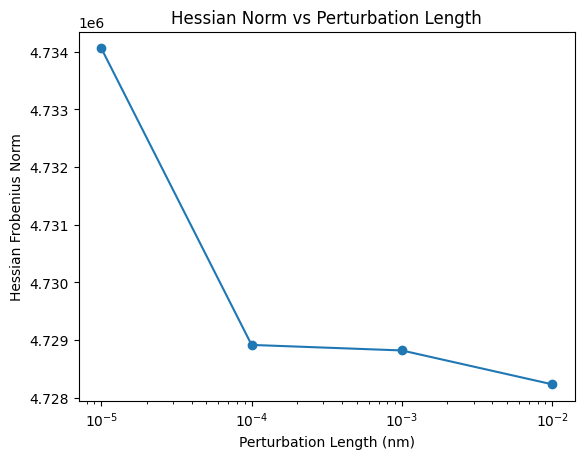

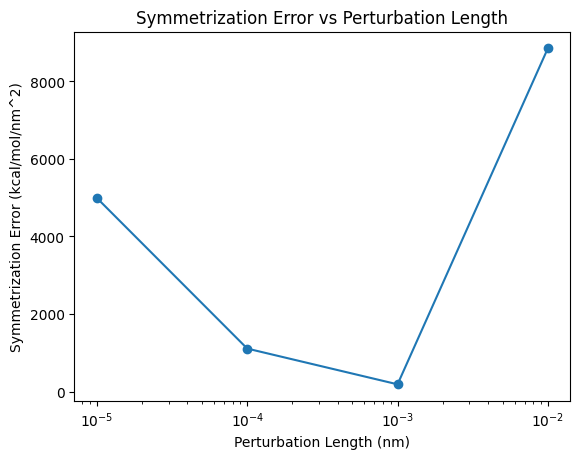

In [22]:
fig, ax = plt.subplots()
ax.plot(lengths, hessian_norms.numpy(), marker="o")
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("Perturbation Length (nm)")
ax.set_ylabel("Hessian Frobenius Norm")
ax.set_title("Hessian Norm vs Perturbation Length")
plt.show()


fig, ax = plt.subplots()
ax.plot(lengths, sym_errors, marker="o")
ax.set_xscale("log")
# ax.set_yscale("log")
ax.set_xlabel("Perturbation Length (nm)")
ax.set_ylabel("Symmetrization Error (kcal/mol/nm^2)")
ax.set_title("Symmetrization Error vs Perturbation Length")
plt.show()